# CardioIA — Fase 2, Parte 2: classificador de risco com TF-IDF

**Grupo Zion** — FIAP, curso de Inteligência Artificial (PBL). Redação e código preparados com apoio de assistente de IA (Claude Code) e revisados pelo grupo.

> ⚠️ **Simulação acadêmica, sem validade clínica.** As frases são sintéticas, escritas pelo grupo. Nada neste notebook serve para triagem, diagnóstico ou decisão médica real.

Este notebook treina e avalia um classificador que lê uma frase de paciente e prevê **alto risco** ou **baixo risco**, e depois o submete a um **conjunto-desafio** desenhado para expor as falhas esperadas de um modelo de saco de palavras (negação, infarto sem dor, gênero da voz, vocabulário novo).

Tudo o que é testado aqui foi **pré-registrado antes de qualquer treino** em [`document/fase-02/protocolo-classificador.md`](../../document/fase-02/protocolo-classificador.md), commitado sozinho, antes deste notebook.

## 1. Setup

Detecta se está rodando no Google Colab ou localmente. Localmente, os arquivos vêm do próprio repositório; no Colab, da URL *raw* do GitHub na branch `main`. A semente é fixa em todo o notebook.

In [1]:
import hashlib
import io
import platform
import sys
import urllib.request
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report,
                             confusion_matrix, f1_score, make_scorer, precision_score, recall_score)
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict,
                                     cross_validate, train_test_split)
from sklearn.pipeline import Pipeline

SEED = 42
ALTO, BAIXO = "alto risco", "baixo risco"
EM_COLAB = "google.colab" in sys.modules
URL_BASE = "https://raw.githubusercontent.com/Cesar-Azeredo/CardioAI/main/"


def raiz_do_repositorio():
    """Sobe a partir do diretório atual até achar a pasta de dados da Fase 2."""
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "document" / "datasets" / "fase-02").is_dir():
            return candidato
    return None


RAIZ = None if EM_COLAB else raiz_do_repositorio()
ORIGEM = "repositório local" if RAIZ is not None else "GitHub (raw, branch main)"


def ler_bytes(caminho_relativo):
    if RAIZ is not None:
        return (RAIZ / caminho_relativo).read_bytes()
    with urllib.request.urlopen(URL_BASE + caminho_relativo) as resposta:
        return resposta.read()


print(f"Ambiente: {'Google Colab' if EM_COLAB else 'local'} — dados lidos de: {ORIGEM}")
print(f"Python {platform.python_version()} ({sys.executable})")
for nome, mod in [("numpy", np), ("pandas", pd), ("scikit-learn", sklearn), ("matplotlib", matplotlib), ("nltk", nltk)]:
    print(f"  {nome:13} {mod.__version__}")
print(f"Semente: {SEED}")

Ambiente: local — dados lidos de: repositório local
Python 3.12.14 (/private/tmp/claude-501/-Users-cesar-VSCode-CardioAI/1190c018-fbac-40dd-82df-ef5172a42552/scratchpad/venv-nb/bin/python3.12)
  numpy         2.0.2
  pandas        2.3.3
  scikit-learn  1.6.1
  matplotlib    3.11.1
  nltk          3.9.1
Semente: 42


## 2. Protocolo pré-registrado (resumo)

Protocolo completo: [`document/fase-02/protocolo-classificador.md`](../../document/fase-02/protocolo-classificador.md). Critério de rótulo: [`document/fase-02/criterio-rotulo-risco.md`](../../document/fase-02/criterio-rotulo-risco.md).

| # | Hipótese | Critério de decisão (fixado antes) |
|---|---|---|
| H1 | **Negação** — frase com sinal de alerta *negado* tende a sair alto risco (falso positivo) | confirmada se ≥ 2 das 3 frases de negação saírem alto risco |
| H2 | **Atípico** — infarto sem "dor" tende a sair baixo risco (**falso negativo, o erro perigoso**) | confirmada se ≥ 2 das 3 frases atípicas saírem baixo risco |
| H3 | **Gênero** — pares idênticos exceto a concordância podem receber predições diferentes | por par: aprovado / reprovado / **inconclusivo** (se as palavras que diferem estão fora do vocabulário) |
| H4 | **Zona cinzenta** — sintomas só de hipertensão | só descrição; não há resposta certa |
| H5 | **Vocabulário novo** — sinal de alerta em palavras ausentes do treino tende a falhar | confirmada se ≥ 2 das 3 saírem baixo risco |

Decisões de método: pré-processamento **sem remoção de stopwords** (a lista da NLTK apaga a negação); TF-IDF ajustado **dentro** de cada divisão (Pipeline); `LogisticRegression` contra um baseline `DummyClassifier`; split fixo 75/25 **e** validação cruzada 5×10; **recall de alto risco como métrica principal**; análises secundárias de bigramas e de limiares fixos (0,5 / 0,4 / 0,3), sem escolher limiar pelo resultado.

**Circularidade declarada:** o dataset e o desafio foram escritos pelo mesmo grupo que escreveu as hipóteses. Resultado bom aqui não prova generalização para relato real de paciente.

## 3. Dados

Os dois CSVs estão **congelados**: o SHA-256 de cada um é conferido contra o valor registrado em `scripts/fase-02/06_verifica_dataset_risco.py`. Divergência gera **aviso**, não interrompe — o notebook precisa rodar na máquina ou no Colab de quem avalia, e a divergência fica visível.

In [2]:
ARQUIVOS = {
    "treino": ("document/datasets/fase-02/frases-rotuladas-risco.csv",
               "1f493de6da6a080845e278d1de2b773ce96ecefa442b94e3e69db5c37404e9da"),
    "desafio": ("document/datasets/fase-02/desafio-risco.csv",
                "c38357f633461401e8857dab3b91cf521478ba9a4313b7ebddf5a53473222f15"),
    "mapa": ("document/datasets/fase-02/mapa-conhecimento-sintomas.csv",
             "79fae46c6cfd8418eaed30b39f8c84f8eca80b9f0e3ac086ceedac18b91d63c3"),
}
dados = {}
for nome, (caminho, esperado) in ARQUIVOS.items():
    conteudo = ler_bytes(caminho)
    encontrado = hashlib.sha256(conteudo).hexdigest()
    if encontrado == esperado:
        print(f"[OK]    {nome:8} SHA-256 confere ({encontrado[:12]}…)")
    else:
        print(f"[AVISO] {nome:8} SHA-256 DIVERGE do congelado\n        esperado   {esperado}\n        encontrado {encontrado}")
    dados[nome] = pd.read_csv(io.BytesIO(conteudo), encoding="utf-8", keep_default_na=False)

treino, desafio, mapa = dados["treino"], dados["desafio"], dados["mapa"]
X, y = treino["frase"], treino["situacao"]
print()
print("Treino:", len(treino), "frases —", y.value_counts().to_dict())
print("Desafio:", len(desafio), "frases —", desafio["situacao"].value_counts().to_dict())
print()
print(pd.crosstab(treino["situacao"], treino["marcador_genero"], margins=True, margins_name="total"))

[OK]    treino   SHA-256 confere (1f493de6da6a…)
[OK]    desafio  SHA-256 confere (c38357f63346…)
[OK]    mapa     SHA-256 confere (79fae46c6cfd…)

Treino: 80 frases — {'alto risco': 40, 'baixo risco': 40}
Desafio: 18 frases — {'alto risco': 10, 'baixo risco': 5, 'indefinido': 3}

marcador_genero  feminino  masculino  neutro  total
situacao                                           
alto risco              7          7      26     40
baixo risco             6          7      27     40
total                  13         14      53     80


## 4. Pipeline e pré-processamento

**Minúsculas e remoção de acentos, sem remoção de stopwords.** A célula abaixo verifica, na própria lista de stopwords do português da NLTK, quais marcadores de negação ela contém — e mostra o que aconteceria com uma frase de negação se a lista fosse aplicada. O IDF já reduz o peso das palavras frequentes, então remover stopwords não é necessário para o modelo funcionar, e aqui seria prejudicial.

O tokenizador padrão do scikit-learn considera palavras de 2 ou mais caracteres; nenhum marcador de negação tem 1 caractere.

O vetorizador fica **dentro** de um `Pipeline`: em cada divisão de treino/teste, o vocabulário e os pesos IDF são aprendidos só com as frases de treino daquela divisão. Ajustar o TF-IDF nas 80 frases antes de dividir vazaria informação do teste para o treino.

In [3]:
dir_nltk = (RAIZ / ".cache" / "nltk_data") if RAIZ is not None else None
if dir_nltk is not None:
    dir_nltk.mkdir(parents=True, exist_ok=True)
    if str(dir_nltk) not in nltk.data.path:
        nltk.data.path.insert(0, str(dir_nltk))
nltk.download("stopwords", download_dir=str(dir_nltk) if dir_nltk else None, quiet=True)
from nltk.corpus import stopwords

STOP_PT = set(stopwords.words("portuguese"))
NEGADORES = ["não", "nem", "nunca", "sem", "nenhum", "nenhuma"]
print(f"Lista de stopwords do português da NLTK: {len(STOP_PT)} palavras")
print("Marcadores de negação que ESTÃO na lista:", [w for w in NEGADORES if w in STOP_PT])
print("Marcadores de negação que não estão:     ", [w for w in NEGADORES if w not in STOP_PT])

exemplo = desafio.loc[desafio["tipo_frase"] == "desafio-negacao", "frase"].iloc[0]
analisador = TfidfVectorizer(lowercase=True, strip_accents="unicode").build_analyzer()
analisador_stop = TfidfVectorizer(lowercase=True, strip_accents="unicode",
                                  stop_words=sorted(analisador(" ".join(STOP_PT)))).build_analyzer()
print()
print("Frase:", exemplo)
print("Tokens SEM remover stopwords:", analisador(exemplo))
print("Tokens REMOVENDO stopwords:  ", analisador_stop(exemplo))


def novo_pipeline(ngram_range=(1, 1)):
    return Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True, strip_accents="unicode", stop_words=None, ngram_range=ngram_range)),
        ("clf", LogisticRegression(random_state=SEED, max_iter=1000)),
    ])


novo_pipeline()

Lista de stopwords do português da NLTK: 207 palavras
Marcadores de negação que ESTÃO na lista: ['não', 'nem', 'sem']
Marcadores de negação que não estão:      ['nunca', 'nenhum', 'nenhuma']

Frase: Não estou com falta de ar nem dor no peito, só uma gripe chata desde domingo.
Tokens SEM remover stopwords: ['nao', 'estou', 'com', 'falta', 'de', 'ar', 'nem', 'dor', 'no', 'peito', 'so', 'uma', 'gripe', 'chata', 'desde', 'domingo']
Tokens REMOVENDO stopwords:   ['falta', 'ar', 'dor', 'peito', 'gripe', 'chata', 'desde', 'domingo']


Pipeline(steps=[('tfidf', TfidfVectorizer(strip_accents='unicode')),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

## 5. Avaliação

### 5.1 Split estratificado fixo 75/25 (semente 42)

60 frases para treino e 20 para teste, mantendo a proporção das classes. É a avaliação que o enunciado pede. **Lembrete:** com 20 frases no teste, cada frase vale 5 pontos percentuais de acurácia — o número deste split sozinho é frágil, e a seção 5.3 mostra quanto ele oscila.

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)
print("Treino:", y_tr.value_counts().to_dict(), "| Teste:", y_te.value_counts().to_dict())

baseline = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
pred_base = baseline.predict(X_te)
print(f"\nBaseline (DummyClassifier most_frequent) chuta sempre: {baseline.predict(X_te[:1])[0]!r}")
print(f"  acurácia {accuracy_score(y_te, pred_base):.3f} | recall de alto risco {recall_score(y_te, pred_base, pos_label=ALTO):.3f}"
      f" | precisão de alto risco {precision_score(y_te, pred_base, pos_label=ALTO, zero_division=0):.3f}")

modelo_split = novo_pipeline().fit(X_tr, y_tr)
pred = modelo_split.predict(X_te)
print(f"\nLogisticRegression — acurácia no teste: {accuracy_score(y_te, pred):.3f}")
print(f"RECALL DE ALTO RISCO (métrica principal): {recall_score(y_te, pred, pos_label=ALTO):.3f}\n")
print(classification_report(y_te, pred, labels=[ALTO, BAIXO], digits=3, zero_division=0))

Treino: {'alto risco': 30, 'baixo risco': 30} | Teste: {'alto risco': 10, 'baixo risco': 10}

Baseline (DummyClassifier most_frequent) chuta sempre: np.str_('alto risco')
  acurácia 0.500 | recall de alto risco 1.000 | precisão de alto risco 0.500

LogisticRegression — acurácia no teste: 0.850
RECALL DE ALTO RISCO (métrica principal): 0.900

              precision    recall  f1-score   support

  alto risco      0.818     0.900     0.857        10
 baixo risco      0.889     0.800     0.842        10

    accuracy                          0.850        20
   macro avg      0.854     0.850     0.850        20
weighted avg      0.854     0.850     0.850        20



### 5.2 Matriz de confusão (split fixo)

Linhas = rótulo verdadeiro; colunas = predição. A célula **alto risco → predito baixo risco** é o falso negativo: o paciente de alto risco triado como baixo risco.

                         predito: alto risco  predito: baixo risco
verdadeiro: alto risco                     9                     1
verdadeiro: baixo risco                    2                     8


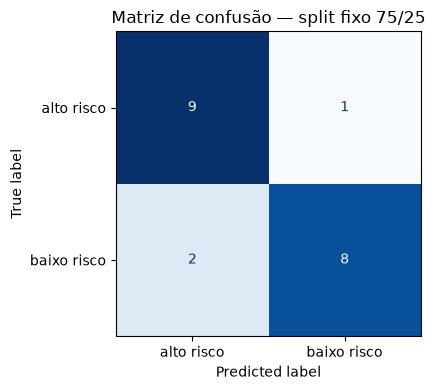

In [5]:
cm = confusion_matrix(y_te, pred, labels=[ALTO, BAIXO])
print(pd.DataFrame(cm, index=[f"verdadeiro: {ALTO}", f"verdadeiro: {BAIXO}"],
                   columns=[f"predito: {ALTO}", f"predito: {BAIXO}"]))
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=[ALTO, BAIXO]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusão — split fixo 75/25")
plt.tight_layout()
plt.show()

### 5.3 Validação cruzada estratificada repetida (5 dobras × 10 repetições)

50 ajustes do pipeline completo, cada um com o TF-IDF aprendido só na dobra de treino. Reporta média e desvio-padrão — é a medida de quanto o número do split único pode variar só pela sorte da divisão.

In [6]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)
METRICAS = {
    "acurácia": "accuracy",
    "recall alto risco": make_scorer(recall_score, pos_label=ALTO),
    "precisão alto risco": make_scorer(precision_score, pos_label=ALTO, zero_division=0),
    "F1 alto risco": make_scorer(f1_score, pos_label=ALTO, zero_division=0),
    "recall baixo risco": make_scorer(recall_score, pos_label=BAIXO),
}


def resumo_cv(estimador):
    r = cross_validate(estimador, X, y, cv=cv, scoring=METRICAS)
    return {m: f"{r['test_' + m].mean():.3f} ± {r['test_' + m].std():.3f}" for m in METRICAS}


tabela_cv = pd.DataFrame({
    "baseline (Dummy)": resumo_cv(DummyClassifier(strategy="most_frequent")),
    "LogisticRegression": resumo_cv(novo_pipeline()),
})
tabela_cv

,baseline (Dummy),LogisticRegression
acurácia,0.500 ± 0.000,0.812 ± 0.084
recall alto risco,1.000 ± 0.000,0.828 ± 0.143
precisão alto risco,0.500 ± 0.000,0.819 ± 0.105
F1 alto risco,0.667 ± 0.000,0.812 ± 0.088
recall baixo risco,0.000 ± 0.000,0.797 ± 0.137


## 6. Interpretação

### 6.1 Falsos negativos — frases de alto risco classificadas como baixo risco

Listadas por extenso: primeiro as do teste do split fixo; depois, para cobrir as 80 frases, as da predição **fora-da-dobra** de uma validação estratificada de 5 dobras (cada frase é prevista por um modelo que não a viu no treino).

In [7]:
fn_split = [(f, p) for f, v, p in zip(X_te, y_te, pred) if v == ALTO and p == BAIXO]
print(f"Split fixo: {len(fn_split)} falso(s) negativo(s) em {sum(y_te == ALTO)} frases de alto risco no teste")
for frase, _ in fn_split:
    print("  -", frase)

pred_oof = cross_val_predict(novo_pipeline(), X, y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED))
fn_oof = treino[(y == ALTO) & (pred_oof == BAIXO)][["frase", "sinal_de_alerta", "tipo_frase", "marcador_genero"]]
fp_oof = treino[(y == BAIXO) & (pred_oof == ALTO)][["frase", "tipo_frase", "marcador_genero"]]
print(f"\nFora-da-dobra (80 frases): {len(fn_oof)} falso(s) negativo(s) e {len(fp_oof)} falso(s) positivo(s)")
with pd.option_context("display.max_colwidth", None):
    display(fn_oof)
    print("Falsos positivos (baixo risco predito como alto risco), para comparação:")
    display(fp_oof)

Split fixo: 1 falso(s) negativo(s) em 10 frases de alto risco no teste
  - Hoje cedo fiquei confusa, não sabia que dia era nem onde tinha deixado as chaves.

Fora-da-dobra (80 frases): 7 falso(s) negativo(s) e 9 falso(s) positivo(s)


,frase,sinal_de_alerta,tipo_frase,marcador_genero
4,Tenho um desconforto no peito que irradia para as costas; começou no meio da reunião e não melhora sentado.,I1,infarto-literal,neutro
11,"Tenho diabetes e hoje, no meio da tarde, bateu um mal-estar súbito com suor gelado; larguei o serviço pela metade.",I7;I3,infarto-literal,neutro
18,"Deu uma dor de cabeça súbita, a pior que já senti, sem motivo nenhum, e vomitei em seguida.",A4,avc-literal,neutro
20,"Hoje cedo fiquei confusa, não sabia que dia era nem onde tinha deixado as chaves.",A1,avc-leigo,feminino
24,"Minha perna direita ficou pesada e arrastando, e quase caí na escada da igreja.",A6;A5,avc-leigo,neutro
33,"Senti falta de ar, depois a visão ficou turva e a perna direita perdeu a força.",I5;A3;A6,combinado,neutro
36,Tive uma dor de cabeça repentina muito forte e agora estou com dificuldade para falar.,A4;A2,avc-leigo,neutro


Falsos positivos (baixo risco predito como alto risco), para comparação:


,frase,tipo_frase,marcador_genero
42,"Voltei moída da caminhada longa de domingo, nada que um banho quente não resolva.",benigno-corpo,feminino
46,Senti o tornozelo esquerdo virar no futebol e o pé inchou um pouco; coloquei gelo e já desinchou.,benigno-corpo,neutro
51,Bati o cotovelo na quina da mesa e ficou uma mancha roxa no braço.,benigno-corpo,neutro
52,"Não sinto dor no peito, o problema é o nariz entupido que não me deixa dormir.",benigno-negacao,neutro
54,Não tive febre nem aperto no peito; é só uma tosse seca que aparece à noite.,benigno-negacao,neutro
59,"Senti uma dor de dente do lado de baixo há dois dias, e ela piora quando tomo algo gelado.",benigno-outro,neutro
63,Tenho uma unha encravada no dedão que inflamou e dói na hora de calçar o tênis.,benigno-outro,neutro
64,Minha pele está ressecada e coçando nos braços desde que começou o inverno.,benigno-corpo,neutro
78,Comi uma fruta que me deu alergia e surgiram umas manchinhas que coçam no braço.,benigno-corpo,neutro


### 6.2 Os 15 maiores coeficientes de cada classe

Modelo ajustado nas 80 frases. Cada termo é classificado pela regra fixa do protocolo (2.f): **sinal clínico** (lista do critério ou palavra de conteúdo de um termo do mapa de conhecimento), **atalho de estilo** (lista do critério), **negação**, ou **fora das listas**.

In [8]:
modelo_final = novo_pipeline().fit(X, y)
vet, clf = modelo_final.named_steps["tfidf"], modelo_final.named_steps["clf"]
termos = vet.get_feature_names_out()
sinal = 1 if list(clf.classes_).index(ALTO) == 1 else -1
peso_alto = sinal * clf.coef_[0]          # positivo empurra para alto risco

sem_acento = lambda w: analisador(w)[0] if analisador(w) else w
CLINICO_CRITERIO = {"repente", "ar", "peso", "fala"}
ESTILO_CRITERIO = {"senti", "meio", "hora", "esquerdo", "doi", "dolorido", "toda"}
NEGACAO = {sem_acento(w) for w in NEGADORES}
stop_sem_acento = {sem_acento(w) for w in STOP_PT}
PALAVRAS_MAPA = {t for col in ("Sintoma 1", "Sintoma 2") for termo in mapa[col] for t in analisador(termo)} - stop_sem_acento


def categoria(t):
    cats = []
    if t in NEGACAO: cats.append("negação")
    if t in ESTILO_CRITERIO: cats.append("atalho de estilo")
    if t in CLINICO_CRITERIO or t in PALAVRAS_MAPA: cats.append("sinal clínico")
    return " / ".join(cats) if cats else "fora das listas"


ordem = np.argsort(peso_alto)
top_alto = pd.DataFrame({"termo": termos[ordem[::-1][:15]], "coeficiente": peso_alto[ordem[::-1][:15]].round(3)})
top_baixo = pd.DataFrame({"termo": termos[ordem[:15]], "coeficiente": peso_alto[ordem[:15]].round(3)})
for df in (top_alto, top_baixo):
    df["categoria"] = df["termo"].map(categoria)
print("Empurram para ALTO risco (coeficiente positivo):")
display(top_alto)
print("Empurram para BAIXO risco (coeficiente negativo):")
display(top_baixo)
print("Contagem por categoria — alto:", top_alto["categoria"].value_counts().to_dict())
print("Contagem por categoria — baixo:", top_baixo["categoria"].value_counts().to_dict())

Empurram para ALTO risco (coeficiente positivo):


,termo,coeficiente,categoria
0,peito,0.776,sinal clínico
1,eu,0.658,fora das listas
2,do,0.650,fora das listas
3,ar,0.493,sinal clínico
4,repente,0.456,sinal clínico
5,cabeca,0.450,sinal clínico
6,suor,0.433,sinal clínico
7,direita,0.368,fora das listas
8,frio,0.356,sinal clínico
9,formigando,0.351,sinal clínico


Empurram para BAIXO risco (coeficiente negativo):


,termo,coeficiente,categoria
0,mas,-0.732,fora das listas
1,quando,-0.566,fora das listas
2,esta,-0.509,fora das listas
3,por,-0.388,fora das listas
4,so,-0.372,fora das listas
5,da,-0.342,fora das listas
6,noite,-0.342,fora das listas
7,com,-0.340,fora das listas
8,incomoda,-0.334,fora das listas
9,tempo,-0.316,fora das listas


Contagem por categoria — alto: {'sinal clínico': 9, 'fora das listas': 6}
Contagem por categoria — baixo: {'fora das listas': 15}


## 7. Conjunto-desafio (H1 a H5)

O modelo final (ajustado nas 80 frases) é aplicado às 18 frases do desafio, que **não entraram no treino**. Cada frase mostra a predição e a probabilidade de alto risco.

In [9]:
p_alto = modelo_final.predict_proba(desafio["frase"])[:, list(clf.classes_).index(ALTO)]
resultado = desafio[["frase", "tipo_frase", "situacao", "marcador_genero", "par_contrafactual"]].copy()
resultado["predito"] = modelo_final.predict(desafio["frase"])
resultado["p(alto risco)"] = p_alto.round(3)
with pd.option_context("display.max_colwidth", None):
    display(resultado.rename(columns={"situacao": "esperado"}))


def decide(tipo, esperado_errado, rotulo):
    sub = resultado[resultado["tipo_frase"] == tipo]
    n = int((sub["predito"] == esperado_errado).sum())
    estado = "CONFIRMADA" if n >= 2 else "NÃO confirmada"
    print(f"{rotulo}: {n} de {len(sub)} frases saíram {esperado_errado!r} → hipótese {estado}")
    return estado


print()
veredito = {}
veredito["H1 negação"] = decide("desafio-negacao", ALTO, "H1 (negação — esperado baixo risco)")
veredito["H2 atípico"] = decide("desafio-atipico", BAIXO, "H2 (infarto atípico sem dor — esperado alto risco)")
g1 = resultado[resultado["par_contrafactual"] == "G1"]
print(f"   par G1 (atípico, sem dor), reportado junto de H2: {g1['predito'].tolist()} — p(alto) {g1['p(alto risco)'].tolist()}")
veredito["H5 vocabulário novo"] = decide("desafio-vocabulario", BAIXO, "H5 (vocabulário novo — esperado alto risco)")
print("\nH4 (zona cinzenta — só descrição, sem resposta certa):")
for _, r in resultado[resultado["tipo_frase"] == "desafio-zona"].iterrows():
    print(f"   p(alto) {r['p(alto risco)']:.3f} → {r['predito']:11} | {r['frase']}")

,frase,tipo_frase,esperado,marcador_genero,par_contrafactual,predito,p(alto risco)
0,"Não estou com falta de ar nem dor no peito, só uma gripe chata desde domingo.",desafio-negacao,baixo risco,neutro,,baixo risco,0.500
1,"Graças a Deus não tive tontura nem fala enrolada, o que sobrou foi um nariz entupido.",desafio-negacao,baixo risco,neutro,,baixo risco,0.489
2,"Sem suor frio, sem aperto e sem desmaio: só uma garganta que arde ao engolir.",desafio-negacao,baixo risco,neutro,,alto risco,0.560
3,"Minha glicose anda descontrolada e desde o almoço estou estranha, suando e sem fôlego, sem dor nenhuma.",desafio-atipico,alto risco,feminino,,alto risco,0.558
4,"Já passei dos setenta e faz uma hora que o ar parece não chegar, com uma canseira que veio do nada.",desafio-atipico,alto risco,neutro,,alto risco,0.573
5,"Desde o café da manhã estou me sentindo esquisito, suando gelado e ofegante, mas não dói nada.",desafio-atipico,alto risco,masculino,,baixo risco,0.466
6,Esta semana o ouvido não para de zumbir e a cabeça lateja de leve quando anoitece.,desafio-zona,indefinido,neutro,,baixo risco,0.439
7,Hoje de manhã escorreu sangue do nariz sem eu ter batido nada.,desafio-zona,indefinido,neutro,,alto risco,0.585
8,"Ando com uma fraqueza geral e uma dor de cabeça chata, mas sem nada de um lado só.",desafio-zona,indefinido,neutro,,baixo risco,0.461
9,Minha boca entortou de repente e sinto a metade da cara amortecida.,desafio-vocabulario,alto risco,neutro,,alto risco,0.547



H1 (negação — esperado baixo risco): 1 de 3 frases saíram 'alto risco' → hipótese NÃO confirmada
H2 (infarto atípico sem dor — esperado alto risco): 1 de 3 frases saíram 'baixo risco' → hipótese NÃO confirmada
   par G1 (atípico, sem dor), reportado junto de H2: ['alto risco', 'alto risco'] — p(alto) [0.577, 0.581]
H5 (vocabulário novo — esperado alto risco): 0 de 3 frases saíram 'baixo risco' → hipótese NÃO confirmada

H4 (zona cinzenta — só descrição, sem resposta certa):
   p(alto) 0.439 → baixo risco | Esta semana o ouvido não para de zumbir e a cabeça lateja de leve quando anoitece.
   p(alto) 0.585 → alto risco  | Hoje de manhã escorreu sangue do nariz sem eu ter batido nada.
   p(alto) 0.461 → baixo risco | Ando com uma fraqueza geral e uma dor de cabeça chata, mas sem nada de um lado só.


### 7.1 H3 — pares contrafactuais de gênero

Regra crítica do protocolo (2.h): para cada par, as duas predições, as duas probabilidades, a diferença, e — para **cada palavra que difere** entre os lados — se ela está no vocabulário do modelo. Se nenhuma das palavras que diferem estiver no vocabulário, o TF-IDF enxerga as duas frases como o mesmo vetor: predição idêntica **por cegueira, não por justiça**. Esse par é **inconclusivo**, não aprovado.

In [10]:
vocab = set(vet.vocabulary_)
linhas_h3 = []
for pid, par in resultado[resultado["par_contrafactual"] != ""].groupby("par_contrafactual"):
    fem = par[par["marcador_genero"] == "feminino"].iloc[0]
    mas = par[par["marcador_genero"] == "masculino"].iloc[0]
    tf, tm = analisador(fem["frase"]), analisador(mas["frase"])
    difere = sorted(set(tf) ^ set(tm))
    no_vocab = {w: (w in vocab) for w in difere}
    informativo = any(no_vocab.values())
    if not informativo:
        veredito_par = "INCONCLUSIVO (palavras que diferem fora do vocabulário)"
    elif fem["predito"] == mas["predito"]:
        veredito_par = "aprovado (predição idêntica)"
    else:
        veredito_par = "REPROVADO (predição difere)"
    linhas_h3.append({
        "par": pid, "esperado": fem["situacao"],
        "predito F": fem["predito"], "predito M": mas["predito"],
        "p(alto) F": fem["p(alto risco)"], "p(alto) M": mas["p(alto risco)"],
        "diferença (F−M)": round(fem["p(alto risco)"] - mas["p(alto risco)"], 3),
        "palavras que diferem → no vocabulário?": ", ".join(f"{w}: {'sim' if v else 'não'}" for w, v in no_vocab.items()),
        "veredito": veredito_par,
    })
tabela_h3 = pd.DataFrame(linhas_h3)
with pd.option_context("display.max_colwidth", None):
    display(tabela_h3)

,par,esperado,predito F,predito M,p(alto) F,p(alto) M,diferença (F−M),palavras que diferem → no vocabulário?,veredito
0,G1,alto risco,alto risco,alto risco,0.577,0.581,-0.004,"diabetica: não, diabetico: não, esquisita: não, esquisito: sim, suada: não, suado: não",aprovado (predição idêntica)
1,G2,alto risco,alto risco,alto risco,0.618,0.616,0.002,"palida: sim, palido: não, suada: não, suado: não",aprovado (predição idêntica)
2,G3,baixo risco,baixo risco,baixo risco,0.345,0.344,0.001,"cansada: não, cansado: sim, gripada: não, gripado: não",aprovado (predição idêntica)


## 8. Análises secundárias (pré-declaradas)

Não substituem o modelo principal. Servem para responder duas perguntas do protocolo (2.i).

### 8.1 Unigramas × unigramas + bigramas

Bigramas como "nao sinto" e "sem dor" guardam um pedaço da ordem das palavras. A pergunta é se isso mitiga H1.

In [11]:
tabela_ngram = pd.DataFrame({
    "unigramas (1,1)": resumo_cv(novo_pipeline((1, 1))),
    "uni + bigramas (1,2)": resumo_cv(novo_pipeline((1, 2))),
})
display(tabela_ngram)

modelo_bi = novo_pipeline((1, 2)).fit(X, y)
neg = desafio[desafio["tipo_frase"] == "desafio-negacao"]
p_bi = modelo_bi.predict_proba(neg["frase"])[:, list(modelo_bi.classes_).index(ALTO)]
comparacao_h1 = pd.DataFrame({
    "frase": neg["frase"].values,
    "p(alto) unigramas": resultado.loc[neg.index, "p(alto risco)"].values,
    "p(alto) uni+bigramas": p_bi.round(3),
    "predito uni+bigramas": modelo_bi.predict(neg["frase"]),
})
with pd.option_context("display.max_colwidth", None):
    display(comparacao_h1)
n_bi = int((comparacao_h1["predito uni+bigramas"] == ALTO).sum())
print(f"H1 com uni+bigramas: {n_bi} de 3 frases de negação saíram alto risco "
      f"→ {'CONFIRMADA' if n_bi >= 2 else 'NÃO confirmada'} também com bigramas")

,"unigramas (1,1)","uni + bigramas (1,2)"
acurácia,0.812 ± 0.084,0.829 ± 0.090
recall alto risco,0.828 ± 0.143,0.835 ± 0.124
precisão alto risco,0.819 ± 0.105,0.837 ± 0.113
F1 alto risco,0.812 ± 0.088,0.829 ± 0.092
recall baixo risco,0.797 ± 0.137,0.823 ± 0.135


,frase,p(alto) unigramas,p(alto) uni+bigramas,predito uni+bigramas
0,"Não estou com falta de ar nem dor no peito, só uma gripe chata desde domingo.",0.500,0.484,baixo risco
1,"Graças a Deus não tive tontura nem fala enrolada, o que sobrou foi um nariz entupido.",0.489,0.482,baixo risco
2,"Sem suor frio, sem aperto e sem desmaio: só uma garganta que arde ao engolir.",0.560,0.535,alto risco


H1 com uni+bigramas: 1 de 3 frases de negação saíram alto risco → NÃO confirmada também com bigramas


### 8.2 Limiares fixos de decisão: 0,5 / 0,4 / 0,3

Baixar o limiar da probabilidade de alto risco troca precisão por recall — em triagem, é a forma de pagar mais falsos positivos para ter menos falsos negativos. Os três limiares foram fixados no protocolo; **nenhum é escolhido pelo resultado** e o modelo principal continua em 0,5. Probabilidades fora-da-dobra de cada uma das 10 repetições da validação cruzada 5×10.

In [12]:
LIMIARES = [0.5, 0.4, 0.3]
por_rep = {lim: {"recall": [], "precisao": []} for lim in LIMIARES}
dobras = list(cv.split(X, y))
for rep in range(10):
    prob = np.zeros(len(X))
    for tr, te in dobras[rep * 5:(rep + 1) * 5]:
        m = clone(novo_pipeline()).fit(X.iloc[tr], y.iloc[tr])
        prob[te] = m.predict_proba(X.iloc[te])[:, list(m.classes_).index(ALTO)]
    for lim in LIMIARES:
        pred_lim = np.where(prob >= lim, ALTO, BAIXO)
        por_rep[lim]["recall"].append(recall_score(y, pred_lim, pos_label=ALTO))
        por_rep[lim]["precisao"].append(precision_score(y, pred_lim, pos_label=ALTO, zero_division=0))
tabela_limiar = pd.DataFrame({
    f"limiar {lim}": {
        "recall alto risco": f"{np.mean(v['recall']):.3f} ± {np.std(v['recall']):.3f}",
        "precisão alto risco": f"{np.mean(v['precisao']):.3f} ± {np.std(v['precisao']):.3f}",
    } for lim, v in por_rep.items()
})
tabela_limiar

,limiar 0.5,limiar 0.4,limiar 0.3
recall alto risco,0.828 ± 0.031,1.000 ± 0.000,1.000 ± 0.000
precisão alto risco,0.805 ± 0.031,0.514 ± 0.008,0.500 ± 0.000


## Análise exploratória pós-hoc — NÃO pré-registrada

> **Esta seção foi adicionada depois da execução única** das seções pré-registradas (0 a 8), a partir do que aquela execução mostrou. Ela **não altera** nenhum teste, critério ou veredito pré-registrado — os números das seções 0 a 8 são os mesmos da execução única. Resultados exploratórios têm **valor de hipótese, não de conclusão**: servem para explicar o que se viu e para orientar trabalho futuro, não para confirmar nada.

Todas as análises usam **a mesma representação do modelo** (o analisador do `TfidfVectorizer`: minúsculas, sem acento, sem remoção de stopwords) — é justamente a lição desta seção.

### a) Palavras funcionais por classe

Em quantas frases de cada classe aparece cada palavra funcional. "Palavra funcional" = palavra da lista de stopwords do português da NLTK, na forma que o modelo vê (sem acento).

In [13]:
tokens_por_frase = [set(analisador(f)) for f in X]


def frases_por_classe(palavra):
    return {c: sum(1 for toks, rot in zip(tokens_por_frase, y) if palavra in toks and rot == c) for c in (ALTO, BAIXO)}


ALVO = ["mas", "eu", "do", "sem", "so", "quando"]
tabela_func = pd.DataFrame({w: frases_por_classe(w) for w in ALVO}).T
tabela_func.columns = ["frases alto risco", "frases baixo risco"]
display(tabela_func)

exclusivas = []
for w in sorted(stop_sem_acento):
    d = frases_por_classe(w)
    if (d[ALTO] == 0) != (d[BAIXO] == 0):
        exclusivas.append({"palavra funcional": w, "classe": ALTO if d[ALTO] else BAIXO, "frases": max(d.values())})
tabela_excl = pd.DataFrame(exclusivas).sort_values("frases", ascending=False).reset_index(drop=True)
print(f"Palavras funcionais que só aparecem numa classe: {len(tabela_excl)}")
display(tabela_excl)

,frases alto risco,frases baixo risco
mas,0,10
eu,7,0
do,13,6
sem,7,2
so,2,6
quando,2,10


Palavras funcionais que só aparecem numa classe: 20


,palavra funcional,classe,frases
0,mas,baixo risco,10
1,eu,alto risco,7
2,por,baixo risco,4
3,mesmo,alto risco,2
4,ate,alto risco,2
5,estava,alto risco,2
6,tinha,alto risco,2
7,foi,baixo risco,1
8,fui,alto risco,1
9,isso,alto risco,1


### b) Contribuição por palavra em três frases do desafio

Contribuição = coeficiente do modelo final × valor TF-IDF da palavra na frase. Positivo empurra para **alto risco**; negativo, para **baixo risco**. A soma das contribuições mais o intercepto dá o logit da probabilidade de alto risco.

In [14]:
intercepto_alto = sinal * clf.intercept_[0]
TRES = {
    "H2 — falso negativo atípico": "ofegante, mas não dói nada",
    "H5 — acerto com vocabulário novo": "As palavras saem trocadas",
    "H1 — negação que errou": "Sem suor frio, sem aperto e sem desmaio",
}
for rotulo, trecho in TRES.items():
    frase = desafio.loc[desafio["frase"].str.contains(trecho, regex=False), "frase"].iloc[0]
    xv = vet.transform([frase]).toarray()[0]
    idx = np.nonzero(xv)[0]
    contrib = pd.DataFrame({"termo": termos[idx], "tf-idf": xv[idx].round(3), "coeficiente": peso_alto[idx].round(3),
                            "contribuição": (xv[idx] * peso_alto[idx]).round(3)}).sort_values("contribuição", ascending=False)
    logit = intercepto_alto + contrib["contribuição"].sum()
    print(f"\n{rotulo}\n  {frase}\n  p(alto risco) = {1 / (1 + np.exp(-logit)):.3f}  (intercepto {intercepto_alto:+.3f})")
    print("  Empurram para ALTO risco:")
    display(contrib[contrib["contribuição"] > 0].reset_index(drop=True))
    print("  Empurram para BAIXO risco:")
    display(contrib[contrib["contribuição"] < 0].sort_values("contribuição").reset_index(drop=True))


H2 — falso negativo atípico
  Desde o café da manhã estou me sentindo esquisito, suando gelado e ofegante, mas não dói nada.
  p(alto risco) = 0.466  (intercepto -0.058)
  Empurram para ALTO risco:


,termo,tf-idf,coeficiente,contribuição
0,nada,0.284,0.199,0.056
1,nao,0.180,0.275,0.050
2,esquisito,0.353,0.122,0.043
3,ofegante,0.353,0.122,0.043
4,suando,0.353,0.123,0.043
5,gelado,0.301,0.095,0.029
6,doi,0.249,0.081,0.020


  Empurram para BAIXO risco:


,termo,tf-idf,coeficiente,contribuição
0,mas,0.225,-0.732,-0.165
1,da,0.202,-0.342,-0.069
2,manha,0.353,-0.129,-0.046
3,estou,0.188,-0.204,-0.038
4,me,0.249,-0.121,-0.030
5,desde,0.218,-0.069,-0.015



H5 — acerto com vocabulário novo
  As palavras saem trocadas e ninguém entende o que eu digo desde o almoço.
  p(alto risco) = 0.597  (intercepto -0.058)
  Empurram para ALTO risco:


...

,termo,tf-idf,coeficiente,contribuição
0,desde,0.389,-0.069,-0.027



H1 — negação que errou
  Sem suor frio, sem aperto e sem desmaio: só uma garganta que arde ao engolir.
  p(alto risco) = 0.559  (intercepto -0.058)
  Empurram para ALTO risco:


,termo,tf-idf,coeficiente,contribuição
0,sem,0.655,0.312,0.204
1,suor,0.234,0.433,0.101
2,frio,0.243,0.356,0.087
3,aperto,0.267,0.170,0.045
4,desmaio,0.332,0.115,0.038
5,que,0.134,0.100,0.013
6,ao,0.303,0.007,0.002


  Empurram para BAIXO risco:


,termo,tf-idf,coeficiente,contribuição
0,so,0.226,-0.372,-0.084
1,garganta,0.303,-0.233,-0.071
2,uma,0.151,-0.262,-0.039


### c) Falsos negativos fora-da-dobra por tipo de quadro

Os falsos negativos da seção 6.1 (predição fora-da-dobra, 5 dobras, semente 42) classificados **pelos códigos de sinal** da coluna `sinal_de_alerta` — não por leitura: só códigos I = **infarto**; só códigos A = **AVC**; os dois = **misto**. E o recall de alto risco separado por tipo de sinal.

In [15]:
tem_I = treino["sinal_de_alerta"].str.contains("I")
tem_A = treino["sinal_de_alerta"].str.contains("A")
quadro = pd.Series(np.select([tem_I & tem_A, tem_I, tem_A], ["misto", "infarto", "AVC"], default="—"), index=treino.index)
eh_alto = y == ALTO
eh_fn = eh_alto & (pred_oof == BAIXO)
print("Falsos negativos fora-da-dobra por quadro:", quadro[eh_fn].value_counts().to_dict(), f"(total {int(eh_fn.sum())})")
with pd.option_context("display.max_colwidth", None):
    display(treino.loc[eh_fn, ["frase", "sinal_de_alerta"]].assign(quadro=quadro[eh_fn]))

grupos = {
    "algum sinal I (infarto ou misto)": eh_alto & tem_I,
    "algum sinal A (AVC ou misto)": eh_alto & tem_A,
    "só sinal I (infarto)": eh_alto & tem_I & ~tem_A,
    "só sinal A (AVC)": eh_alto & tem_A & ~tem_I,
    "misto (I e A)": eh_alto & tem_I & tem_A,
}
recall_quadro = pd.DataFrame([{"grupo": g, "n": int(m.sum()), "acertos": int((m & (pred_oof == ALTO)).sum()),
                               "recall alto risco": round((m & (pred_oof == ALTO)).sum() / m.sum(), 3)} for g, m in grupos.items()])
recall_quadro

Falsos negativos fora-da-dobra por quadro: {'AVC': 4, 'infarto': 2, 'misto': 1} (total 7)


,frase,sinal_de_alerta,quadro
4,Tenho um desconforto no peito que irradia para as costas; começou no meio da reunião e não melhora sentado.,I1,infarto
11,"Tenho diabetes e hoje, no meio da tarde, bateu um mal-estar súbito com suor gelado; larguei o serviço pela metade.",I7;I3,infarto
18,"Deu uma dor de cabeça súbita, a pior que já senti, sem motivo nenhum, e vomitei em seguida.",A4,AVC
20,"Hoje cedo fiquei confusa, não sabia que dia era nem onde tinha deixado as chaves.",A1,AVC
24,"Minha perna direita ficou pesada e arrastando, e quase caí na escada da igreja.",A6;A5,AVC
33,"Senti falta de ar, depois a visão ficou turva e a perna direita perdeu a força.",I5;A3;A6,misto
36,Tive uma dor de cabeça repentina muito forte e agora estou com dificuldade para falar.,A4;A2,AVC


,grupo,n,acertos,recall alto risco
0,algum sinal I (infarto ou misto),22,19,0.864
1,algum sinal A (AVC ou misto),23,18,0.783
2,só sinal I (infarto),17,15,0.882
3,só sinal A (AVC),18,14,0.778
4,misto (I e A),5,4,0.800


### d) Recall de alto risco por gênero da voz (`marcador_genero`)

Mesmas predições fora-da-dobra. **Com n tão pequeno (7, 7 e 26 frases de alto risco), qualquer diferença entre os grupos não tem poder estatístico** — um único erro muda o recall de um grupo em 14 pontos percentuais. Isto é **demonstração de método**, não resultado.

Isto cumpre, no único eixo demográfico disponível neste dataset (o gênero da voz), o compromisso assumido na Fase 1 de reportar **métricas estratificadas por sexo** em vez de só acurácia global (tabela de mitigações de `document/fase-01/governanca-e-vies.md`; ver `document/fase-02/governanca-e-vies.md`).

In [16]:
recall_genero = pd.DataFrame([
    {"marcador_genero": g, "n (alto risco)": int(m.sum()), "acertos": int((m & (pred_oof == ALTO)).sum()),
     "recall alto risco": round((m & (pred_oof == ALTO)).sum() / m.sum(), 3)}
    for g in ("feminino", "masculino", "neutro") for m in [eh_alto & (treino["marcador_genero"] == g)]
])
recall_genero

,marcador_genero,n (alto risco),acertos,recall alto risco
0,feminino,7,6,0.857
1,masculino,7,7,1.000
2,neutro,26,20,0.769


## 9. Conclusões

### 9.1 Veredito das hipóteses (gerado a partir das células acima)

In [17]:
veredito["H3 gênero"] = "; ".join(f"{r['par']}: {r['veredito']}" for _, r in tabela_h3.iterrows())
veredito["H4 zona cinzenta"] = "só descrição (seção 7)"
pd.DataFrame({"resultado": veredito})

,resultado
H1 negação,NÃO confirmada
H2 atípico,NÃO confirmada
H5 vocabulário novo,NÃO confirmada
H3 gênero,G1: aprovado (predição idêntica); G2: aprovado...
H4 zona cinzenta,só descrição (seção 7)


### 9.2 Leitura dos resultados

*Texto escrito pelo grupo **depois** da execução única das seções 0 a 8, a partir dos números acima. Nenhum número, hipótese ou decisão pré-registrada foi alterado depois de ver o resultado. O que vem da seção pós-hoc está marcado como tal e tem valor de hipótese.*

**Desempenho geral.** No split fixo, acurácia 0,850 e **recall de alto risco 0,900** (9 de 10), com 1 falso negativo: "Hoje cedo fiquei confusa, não sabia que dia era…" (confusão mental, sinal A1, sem nenhuma palavra de dor, peito ou ar). A validação cruzada 5×10 mostra que esse número é otimista e instável: acurácia **0,812 ± 0,084** e recall de alto risco **0,828 ± 0,143** — o split único caiu do lado bom da variação. O baseline chuta sempre "alto risco": recall 1,000 com precisão 0,500 e acurácia 0,500 — prova de que **recall sozinho não basta**; ele é a métrica principal, mas sempre lido junto da precisão.

**Hipóteses (critérios pré-registrados).**
- **H1 (negação): não confirmada** — 1 de 3 saiu alto risco. As três probabilidades ficaram entre 0,489 e 0,560: o modelo não "entendeu" a negação, ficou indeciso. A que errou ("Sem suor frio, sem aperto e sem desmaio…") errou puxada pelo próprio "sem", que no treino aparece mais em frases de alto risco ("sem ar", "sem conseguir"). Bigramas não mudaram o quadro (1 de 3).
- **H2 (atípico): não confirmada** — 1 de 3 saiu baixo risco, e o par G1 saiu alto risco nas duas versões. O erro que aconteceu é exatamente o perigoso: "…suando gelado e ofegante, **mas** não dói nada" → baixo risco (p = 0,466).
- **H3 (gênero): os três pares foram aprovados pelo critério do protocolo** (predição idêntica; diferença de probabilidade ≤ 0,004). Ressalva abaixo.
- **H4 (zona cinzenta):** "escorreu sangue do nariz…" saiu alto risco (0,585); as outras duas, baixo risco (0,439 e 0,461). Sem resposta certa; o comportamento não é estável.
- **H5 (vocabulário novo): não confirmada** — 3 de 3 saíram alto risco. Mas ao menos um acerto foi pelo motivo errado (abaixo).

**"mas" não é ruído de estilo: é o critério de rótulo vazando para a sintaxe.** No treino, "mas" aparece em **0 frases de alto risco e em 10 de baixo risco** (seção pós-hoc, a) e é o coeficiente mais forte para baixo risco (−0,732). O critério define baixo risco como queixa **"autolimitada"**, e é com "mas" que se diz isso em português ("dói, mas melhora quando deito"). O modelo aprendeu que **quem relativiza o sintoma está bem** — e o falso negativo do H2 é justamente um paciente que minimizou ("…mas não dói nada"); na decomposição da seção pós-hoc (b), "mas" é a contribuição que mais o empurra para baixo risco. A declaração da American Heart Association já referenciada no critério (Mehta et al., 2016) descreve, entre os fatores de atraso na busca por atendimento, interpretar os sintomas como não urgentes e passageiros (seção *Factors Associated With Delay*), e relata mulheres jovens com medo de parecerem hipocondríacas (seção *Symptoms of AMI*) — paráfrase verificada pelo grupo na página da editora. **Um modelo que aprende "mas → baixo risco" falha com o paciente que minimiza, que é o que já chega tarde.**

**"eu" no H5 é efeito Clever Hans.** "eu" aparece em 7 frases de alto risco e 0 de baixo (pós-hoc, a). Na frase "As palavras saem trocadas e ninguém entende o que eu digo…", a maior contribuição para alto risco é o "eu" (pós-hoc, b) — o modelo acertou pelo motivo errado, não por reconhecer alteração de fala. **Acerto por motivo errado não conta como evidência a favor do modelo**: com outro pronome, a mesma queixa poderia sair baixo risco.

**Dependência de "peito" e o ponto fraco em AVC.** "peito" é o maior coeficiente para alto risco (0,776). Dos 7 falsos negativos fora-da-dobra, **4 são de AVC, 2 de infarto e 1 misto** pelos códigos de sinal (pós-hoc, c), e seis dos sete não têm a palavra "peito". O recall de alto risco é **0,783 nas frases com algum sinal de AVC** (18 de 23) contra **0,864 nas com algum sinal de infarto** (19 de 22). O erro se concentra em AVC — um risco clínico direto, porque AVC é tempo-dependente. "Cego para AVC" seria exagero diante de um recall de 0,78, e com n = 22 e 23 a diferença não tem poder estatístico; mas o padrão é consistente com o modelo ter aprendido o vocabulário do infarto clássico.

**Gênero: a aprovação do H3 é fraca.** Sem radicalização, "pálida" e "pálido" são, para o TF-IDF, palavras sem relação nenhuma; em cada par só um dos lados tem a palavra de gênero no vocabulário (G1: "esquisito"; G2: "palida"; G3: "cansado") e a marca do outro lado fica invisível. O teste mostra que essas palavras pesam pouco, não que o modelo trate os dois gêneros igualmente. O recall por gênero da voz (pós-hoc, d) — 0,857 feminino (6 de 7), 1,000 masculino (7 de 7), 0,769 neutro (20 de 26) — não tem poder estatístico com esses n; é demonstração do método de estratificação que a Fase 1 prometeu. **Mitigação possível, não implementada:** radicalizar antes do TF-IDF. O extrator da Parte 1 usa o RSLP, cujo passo de redução de feminino une as duas formas — conferido nas 12 palavras dos pares (diabética/diabético → `diabe`, pálida/pálido → `pal`, esquisita/esquisito → `esquisit`, suada/suado → `su`, cansada/cansado → `cans`, gripada/gripado → `grip`). Com essa representação o contrafactual deixaria de ser invisível de um lado e passaria a ser idêntico por construção.

**Ponto cego da verificação — lição de processo.** A tabela de atalhos do dataset (`scripts/fase-02/06_verifica_dataset_risco.py`) contava só palavras de conteúdo, sem stopwords; este protocolo mantém as stopwords, para não apagar a negação. Duas decisões corretas isoladamente criaram juntas o ponto cego que deixou "mas" e "eu" passarem. **A verificação do dado tem que usar a mesma representação que o modelo vai usar.** O script 06 ganhou uma seção informativa de palavras funcionais por classe, na representação do classificador. Por decisão do grupo, **o dataset não ganha versão 2**: a regra de parada do balanceamento existe para impedir esse ciclo, o enunciado pede observar padrões e distorções — este é o principal —, e corrigir apagaria o achado.

**Probabilidades pouco espalhadas.** No desafio, todas as probabilidades ficaram entre 0,34 e 0,62; por isso a análise de limiares degenera (em 0,4 o recall já é 1,000 com precisão 0,514; em 0,3 tudo é alto risco). Com 80 frases e regularização padrão, a probabilidade da regressão logística **não** deve ser lida como risco clínico calibrado.

**Conclusão.** O classificador separa bem as frases do próprio dataset (≈ 0,81 de acurácia na validação cruzada), mas aprende em parte o jeito de escrever do grupo ("mas" → baixo risco, "eu" → alto risco) e o vocabulário do infarto clássico ("peito", "ar", "suor"). As falhas perigosas — o paciente que minimiza o sintoma e o AVC sem "peito" — aparecem mesmo onde a hipótese formal não se confirmou pelo critério de maioria.

### 9.3 Limitações

- **n pequeno.** 80 frases; no split fixo, 20 de teste (cada frase = 5 pontos percentuais). A validação cruzada repetida mostra a oscilação, mas não cria dado novo.
- **Circularidade de autoria.** Frases, rótulos, desafio e hipóteses foram escritos pelo mesmo grupo. O modelo aprende o jeito de escrever do grupo; o desempenho aqui não é evidência de desempenho em relato real.
- **Zona cinzenta excluída do treino.** Sintomas só de hipertensão ficaram fora, o que torna a tarefa mais fácil que a triagem real — a acurácia medida **superestima** o uso real.
- **Saco de palavras.** O TF-IDF não vê ordem nem escopo de negação (a não ser parcialmente, com bigramas).
- **Atalhos de palavra funcional.** "mas" (0 alto / 10 baixo) e "eu" (7 / 0) viraram atalhos que a verificação do dataset não via; registrados como resultado, sem nova versão do dataset.

### 9.4 Ligação com a Fase 1 e com a Fase 5

- **Fase 1:** a assimetria de custo documentada lá é o motivo de o recall de alto risco ser a métrica principal, e o viés de gênero da base Cleveland (68% masculina) é o motivo do teste contrafactual. A estratificação do recall por gênero da voz (seção pós-hoc, d) cumpre, no único eixo demográfico deste dataset, o compromisso da Fase 1 de métricas estratificadas por sexo.
- **Fase 5 (chatbot):** o extrator da Parte 1 e este classificador são peças de triagem que um assistente virtual usaria; as falhas encontradas aqui (negação, infarto sem dor, vocabulário novo) são requisitos para ele — em particular, nenhum chatbot deve dar "baixo risco" a um relato só porque ele não contém a palavra "dor", nem porque o paciente relativizou o sintoma com um "mas".